#   Vision Classification Pipeline — Computer Vision Project Tracker

##  ✅ Phase 1 — Setup & Data Pipeline

In [1]:
import pandas as pd
train = pd.read_csv('D:\\Coding\\vision-classification-pipeline\\src\\train.csv')
print(train.shape)
print(train.head())
#   each row = one image = 1 label + 784 pixel values

(42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0      

Label: 0.0


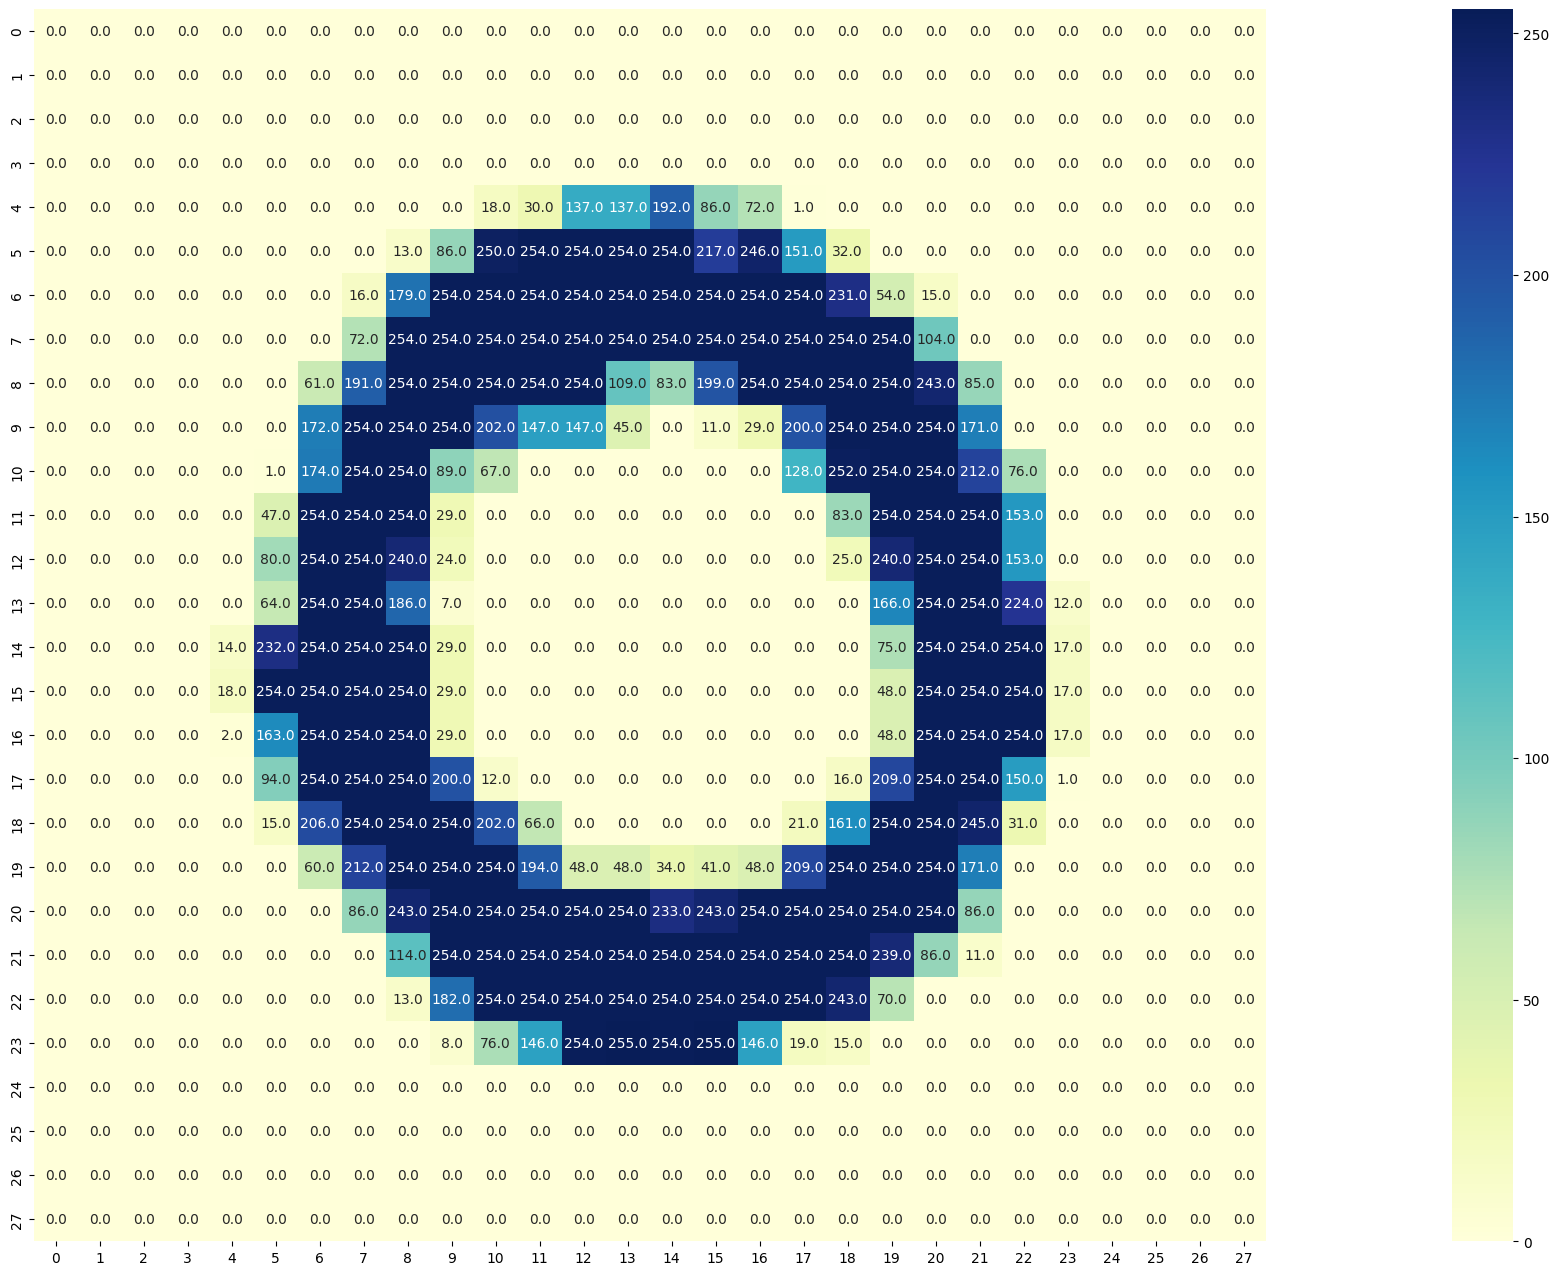

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# 1. Load the CSV file (Skip the header row if your CSV has one)
# Replace ',' with your actual delimiter if it is different (e.g., ';' or '\t')
data = np.loadtxt('D:\\Coding\\vision-classification-pipeline\\src\\train.csv', delimiter=',', skiprows=1)

# 2. Choose your instance index
i = 1 

# 3. Separate your features (X) and labels (Y) 
# ASSUMPTION: The first column is the label, and the remaining columns are pixels
label = data[i, 0]
flat_image = data[i, 1:]

# 4. Reshape the flat 1D array into a 2D image matrix
# Change (28, 28) to your image's actual height and width dimensions
image = flat_image.reshape(28, 28)

print(f"Label: {label}") 

# 5. Display the heatmap
f, ax = plt.subplots(figsize=(48, 16)) 
sns.heatmap(image, annot=True, fmt='.1f', square=True, cmap="YlGnBu") 
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt


X = train.drop(columns=['label']).to_numpy(dtype=np.float32)
y = train['label'].to_numpy()

# Reshape all rows into 28x28 images
X_imgs = X.reshape(-1, 28, 28)

print("X shape:", X.shape)
print("X_imgs shape:", X_imgs.shape)
print("label sample:", y[:5])

X shape: (42000, 784)
X_imgs shape: (42000, 28, 28)
label sample: [1 0 1 4 0]


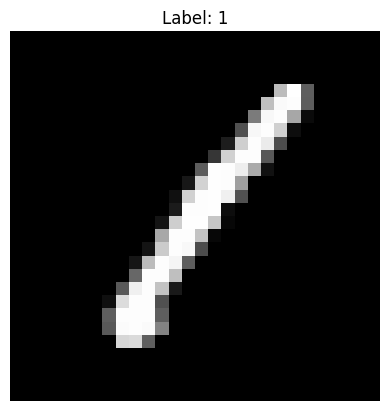

In [4]:
sample_idx = 0
plt.imshow(X_imgs[sample_idx], cmap='gray')
plt.title(f"Label: {y[sample_idx]}")
plt.axis('off')
plt.show()

In [5]:
"""Normalization"""

X = train.drop(columns=['label']).to_numpy(dtype=np.float32)
y = train['label'].to_numpy()

X_norm = X / 255.0
print("Normalized range:", X_norm.min(), X_norm.max())
print("X_norm shape:", X_norm.shape)

X_norm_reshaped = X_norm.reshape(-1, 28, 28, 1)
print("X_norm_reshaped shape:", X_norm_reshaped.shape)

Normalized range: 0.0 1.0
X_norm shape: (42000, 784)
X_norm_reshaped shape: (42000, 28, 28, 1)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_norm, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (33600, 784)
X_val: (8400, 784)
y_train: (33600,)
y_val: (8400,)


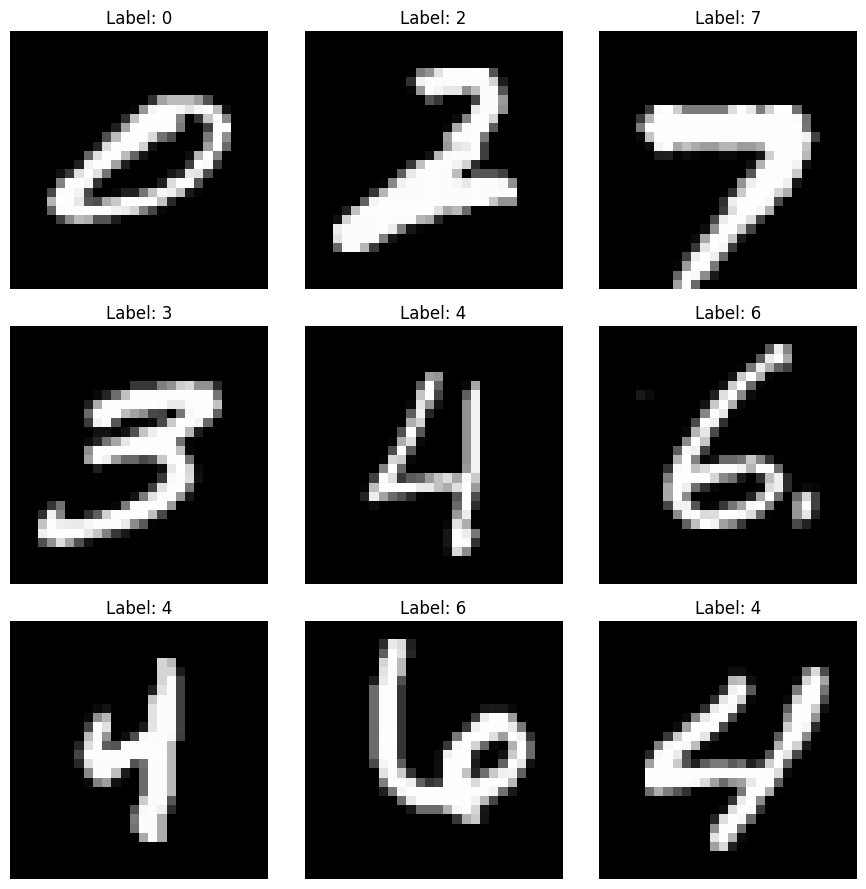

In [7]:
import matplotlib.pyplot as plt
import numpy as np

sample_indices = np.random.choice(len(X_train), 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.ravel()

for ax, idx in zip(axes, sample_indices):
    img = X_train[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

##  ✅ Phase 2 — Build CNN

In [14]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([keras.Input(shape=(28, 28)),
                          layers.Reshape((28, 28, 1)),
                          layers.Conv2D(32, kernel_size= 3, activation= 'relu', padding = 'same'),
                          layers.MaxPooling2D(),
                          layers.Conv2D(filters = 64, kernel_size= 3, activation= 'relu', padding = 'same'),
                          layers.MaxPooling2D(),
                          layers.Flatten(),
                          layers.Dense(128, activation= 'relu'),
                          layers.Dropout(0.3),
                          layers.Dense(10, activation = 'softmax')
                          ])
print(model.summary())

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
import os
import shutil

GRAPHVIZ_BIN = r"C:\Program Files\Graphviz\bin"
if os.path.isdir(GRAPHVIZ_BIN):
    os.environ["PATH"] = GRAPHVIZ_BIN + os.pathsep + os.environ.get("PATH", "")

print("dot:", shutil.which("dot"))

dot: C:\Program Files\Graphviz\bin\dot.EXE


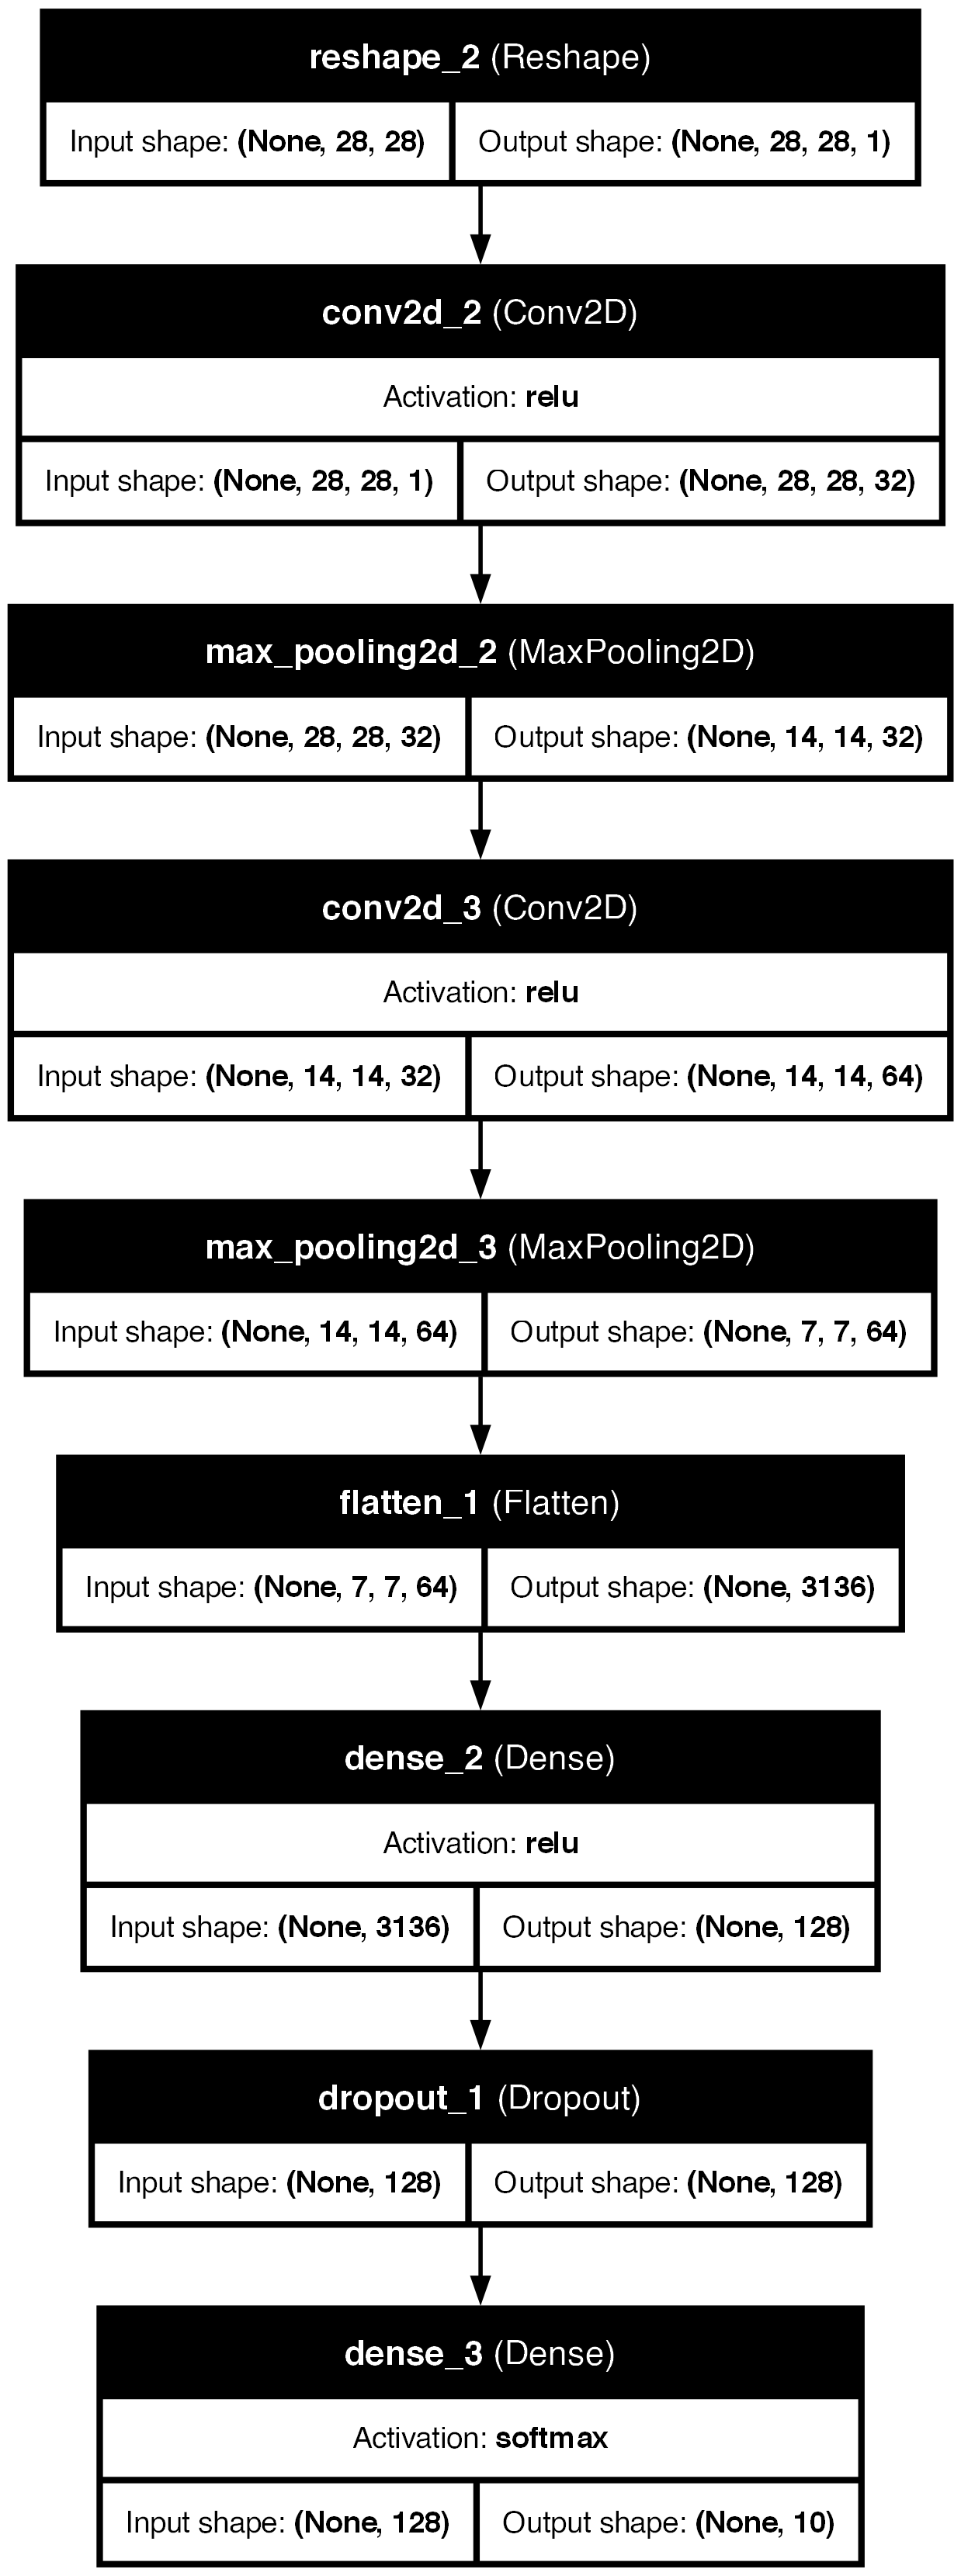

In [24]:
from tensorflow.keras.utils import plot_model

# This will generate the image and display it in your notebook
plot_model(model, 
            
           show_shapes=True, 
           show_layer_names=True,
           show_layer_activations=True)